In [ ]:
import numpy as np
from pyscf import lib, gto, scf, mp

import basis_set_exchange as bse

def bse_basis(name, elements):
    """Return a PySCF basis dict for the given elements from BSE."""
    out = {}
    for el in set(elements):
        raw = bse.get_basis(name, elements=[el], fmt='nwchem', header=False)
        out[el] = gto.basis.parse(raw)
    return out

In [6]:
print(bse.get_references('x2c-tzvpall', elements=['Fe'], fmt='txt'))


 If you downloaded data from the basis set
 exchange or used the basis set exchange python library, please cite:

pritchard2019a
    Pritchard, Benjamin P., Altarawy, Doaa, Didier, Brett, Gibsom, Tara
            D., Windus, Theresa L.
    A New Basis Set Exchange: An Open, Up-to-date Resource for the
            Molecular Sciences Community
    J. Chem. Inf. Model. 59, 4814-4820 (2019)
    10.1021/acs.jcim.9b00725

feller1996a
    Feller, David
    The role of databases in support of computational chemistry
            calculations
    J. Comput. Chem. 17, 1571-1586 (1996)
    10.1002/(SICI)1096-987X(199610)17:13<1571::AID-JCC9>3.0.CO;2-P

schuchardt2007a
    Schuchardt, Karen L., Didier, Brett T., Elsethagen, Todd, Sun, Lisong,
            Gurumoorthi, Vidhya, Chase, Jared, Li, Jun, Windus, Theresa L.
    Basis Set Exchange: A Community Database for Computational Sciences
    J. Chem. Inf. Model. 47, 1045-1052 (2007)
    10.1021/ci600510j


 References for the basis set

 Fe
     x2

In [ ]:
path2chk = "./hs_tdz_mf.chk"
mol = lib.chkfile.load_mol(path2chk)
mol.basis = {'default': 'x2c-svpall', 'Fe': 'x2c-tzvpall'}
mol.nucmod = 'G'
mol.build()

mf = scf.UHF(mol).x2c().density_fit()
mf.chkfile = './hs_tzvp_mf.chk'
mf.max_cycle = 100
mf.level_shift = 0.5
mf = mf.newton()
mf.kernel()

stable = False
for i in range(10):
    print(f'mf stability test {i+1}')
    if not stable:
        mo_i, _, stable,_ = mf.stability(return_status=True)
        dm = mf.make_rdm1(mo_i,mf.mo_occ)
        mf = mf.newton()
        mf.kernel(dm0=dm)
    elif stable:
        print(f'mf energy: {mf.e_tot}, stability {stable}')
        break





******** <class 'pyscf.soscf.newton_ah.SecondOrderDFsfX2C1eUHF'> ********
method = SecondOrderDFsfX2C1eUHF
initial guess = minao
damping factor = 0
level_shift factor = 0.5
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 100
direct_scf = False
chkfile to save SCF result = ./hs_tzvp_mf.chk


max_memory 20000 MB (current use 752 MB)
number electrons alpha = 44  beta = 40


******** <class 'pyscf.x2c.sfx2c1e.SpinFreeX2CHelper'> ********
approx = 1e
xuncontract = 1
******** <class 'pyscf.df.df_jk.DFsfX2C1eUHF'> Newton solver flags ********
SCF tol = 1e-09
conv_tol_grad = None
max. SCF cycles = 100
direct_scf = False
chkfile to save SCF result = ./hs_tzvp_mf.chk
max_cycle_inner = 12
max_stepsize = 0.05
ah_start_tol = 1e+09
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_start_cycle = 1
ah_max_cycle = 40
ah_grad_trust_region = 2.5
kf_interval = 4
kf_trust_region = 5
canonicalization = True
max_memory 20000 MB (current use 752 MB)
Set conv_tol_grad to 3.16228e-05
******** <class 'pyscf.df.df.DF'> ********
auxbasis = None
max_memory = 20000
ETB for Fe: l = 0, exps = 0.086289793544 * 2^n , n = 0..20
ETB for Fe: l = 1, exps = 0.11995701718281195 * 2^n , n = 0..17
ETB for Fe: l = 2, exps = 0.1253185637685335 * 2^n , n = 0..15
ETB for Fe: l = 3, exps = 0.17421343231794728

In [28]:
mol.nao

192

In [29]:
mymp = mp.MP2(mf).set_frozen()
mymp.kernel()
print(mymp.e_corr)


******** <class 'pyscf.mp.dfump2.DFUMP2'> ********
nocc = (np.int64(33), np.int64(29)), nmo = (181, 181)
frozen orbitals 11
max_memory 20000 MB (current use 961 MB)
E(DFUMP2) = -1728.75315661864  E_corr = -1.62009842965636
E(SCS-DFUMP2) = -1728.681131703  E_corr = -1.54807351402133
E_corr(same-spin) = -0.45697454026881
E_corr(oppo-spin) = -1.16312388938755
-1.620098429656359


In [30]:
from pyscf.data import elements
elements.chemcore(mol)

11

In [31]:
options = {
           'eql_time': 40,
           'n_blocks': 50,
           'n_walkers': 100,
           'mix_precision': True,
           'max_memory': 300000,
           'seed': 17,
           'walker_type': 'uhf',
           'trial': 'upt2ccsd',
           }

from afqmc.lno_afqmc import tools, lno_afqmc_test

In [32]:
lo_coeff, frag_list, frag_name = tools.iao_fragment(
        mf,
        frag_type='h2heavy',
        more_loc='pm',
        x2c=True,
        save2=None,
        read_from=None,
        )

threshs = [1e-4, 3e-5, 1e-5, 3e-6, 1e-6, 3e-7]
emp1 = np.zeros(len(threshs))
size1 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    # lno_thresh = [lno_thresh, lno_thresh]
    emp1[i], _, _, _, size1[i] \
        = lno_afqmc_test.run_afqmc(
                mf,
                lo_coeff,
                frag_list,
                frag_name,
                lno_thresh = lno_thresh,
                qmc_options = options,
                chol_cut = 1e-5,
                target_qmc_err = 5e-4,
                run_frag = None,
                nfrozen = None,
                run_mp = True,
                run_cc = False,
                run_qmc = False,
                plot_las = False,
                )



Detected basis set not in the cc-pVXZ family. Run free atom scf to generate reference basis.
Detected relativistic basis set. Run free atom scf with scalar relativistic (sfX2C1e) effects.


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 55.003188698107  |g|= 0.0431115
macro= 1  f(x)= 55.009036088917  delta_f= 0.00584739  |g|= 0.0227481  5 KF 27 Hx
macro= 2  f(x)= 55.010073687809  delta_f= 0.0010376  |g|= 0.00393603  5 KF 31 Hx
macro= 3  f(x)= 55.010139748799  delta_f= 6.6061e-05  |g|= 0.000362858  6 KF 35 Hx
macro= 4  f(x)= 55.010140500579  delta_f= 7.5178e-07  |g|= 0.000119138  5 KF 26 Hx
macro X = 

[ 42.  58.  92. 113. 126. 160.]
[-1.57885054 -1.59095629 -1.60741969 -1.61650203 -1.61870553 -1.61966452]
-1.620098429656359


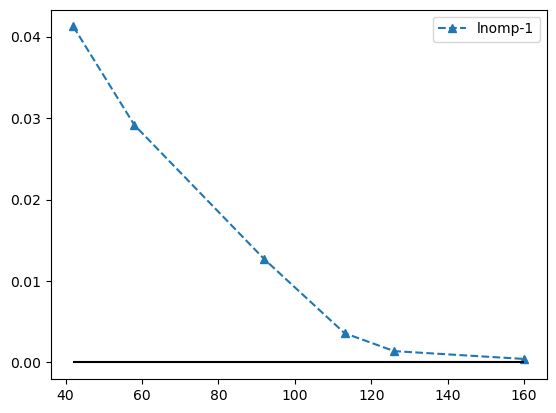

In [33]:
print(size1)
print(emp1)
print(mymp.e_corr)

from matplotlib import pyplot as plt
plt.plot(size1, emp1-mymp.e_corr, "^--", color="C0", label="lnomp-1")
plt.hlines(0, xmin=min(np.hstack((size1))), xmax=max(np.hstack((size1))), colors='k')
plt.legend()
plt.show()

In [ ]:
path2chk = "./hs_mf.chk"
mol = lib.chkfile.load_mol(path2chk)
mol.basis = {'default': 'x2c-tzvpall', 'Fe': 'x2c-tzvpall'}
mol.nucmod = 'G'
mol.build()

mf = scf.UHF(mol).x2c().density_fit()
mf.chkfile = './hs_tzvp_mf.chk'
mf.init_guess = 'chk'
mf.max_cycle = 100
mf.level_shift = 0.5
mf = mf.newton()
mf.kernel()



******** <class 'pyscf.soscf.newton_ah.SecondOrderDFsfX2C1eUHF'> ********
method = SecondOrderDFsfX2C1eUHF
initial guess = chk
damping factor = 0
level_shift factor = 0.5
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 100
direct_scf = False
chkfile to save SCF result = ./hs_tzvp_mf.chk
max_memory 20000 MB (current use 4662 MB)
number electrons alpha = 44  beta = 40


******** <class 'pyscf.x2c.sfx2c1e.SpinFreeX2CHelper'> ********
approx = 1e
xuncontract = 1
******** <class 'pyscf.df.df_jk.DFsfX2C1eUHF'> Newton solver flags ********
SCF tol = 1e-09
conv_tol_grad = None
max. SCF cycles = 100
direct_scf = False
chkfile to save SCF result = ./hs_tzvp_mf.chk
max_cycle_inner = 12
max_stepsize = 0.05
ah_start_tol = 1e+09
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_start_cycle = 1
ah_max_cycle = 40
ah_grad_trust_region = 2.5
kf_interval = 4
kf_trust_region = 5
canonicalizat

np.float64(-1727.6774092331)

In [40]:
lo_coeff, frag_list, frag_name = tools.iao_fragment(
        mf,
        frag_type='h2heavy',
        more_loc='pm',
        x2c=True,
        save2=None,
        read_from=None,
        )

emp2 = np.zeros(len(threshs))
size2 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):

    emp2[i], _, _, _, size2[i] \
        = lno_afqmc_test.run_afqmc(
                mf,
                lo_coeff,
                frag_list,
                frag_name,
                lno_thresh = lno_thresh,
                qmc_options = options,
                chol_cut = 1e-5,
                target_qmc_err = 5e-4,
                run_frag = None,
                nfrozen = None,
                run_mp = True,
                run_cc = False,
                run_qmc = False,
                plot_las = False,
                )

Detected basis set not in the cc-pVXZ family. Run free atom scf to generate reference basis.
Detected relativistic basis set. Run free atom scf with scalar relativistic (sfX2C1e) effects.


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 55.046955024667  |g|= 0.0421322
macro= 1  f(x)= 55.051608822891  delta_f= 0.0046538  |g|= 0.00772903  6 KF 29 Hx
macro= 2  f(x)= 55.052550891668  delta_f= 0.000942069  |g|= 0.00270176  5 KF 31 Hx
macro= 3  f(x)= 55.052634392676  delta_f= 8.3501e-05  |g|= 0.00041348  6 KF 35 Hx
macro= 4  f(x)= 55.052635371815  delta_f= 9.79139e-07  |g|= 0.000200784  4 KF 22 Hx
macro X 

In [39]:
mymp2 = mp.MP2(mf).set_frozen()
mymp2.kernel()
print(mymp2.e_corr)


******** <class 'pyscf.mp.dfump2.DFUMP2'> ********
nocc = (np.int64(33), np.int64(29)), nmo = (295, 295)
frozen orbitals 11
max_memory 20000 MB (current use 5309 MB)
E(DFUMP2) = -1729.59737823142  E_corr = -1.91996899832021
E(SCS-DFUMP2) = -1729.5277499501  E_corr = -1.85034071700142
E_corr(same-spin) = -0.523410093441731
E_corr(oppo-spin) = -1.39655890487848
-1.9199689983202086


[ 42.  58.  92. 113. 126. 160.]
[-1.57885054 -1.59095629 -1.60741969 -1.61650203 -1.61870553 -1.61966452]
[ 44.  67. 101. 120. 140. 182.]
[-1.86245473 -1.88445273 -1.90579809 -1.9143387  -1.9174443  -1.91868267]


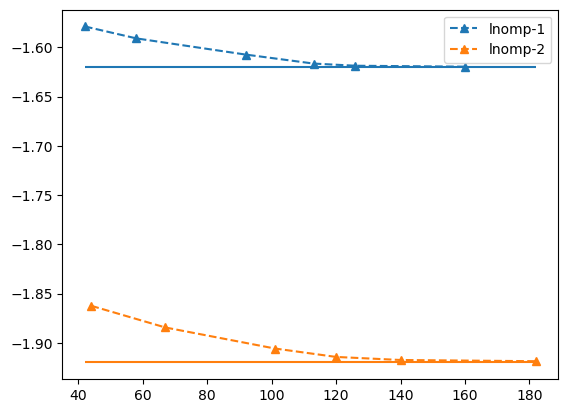

In [41]:
print(size1)
print(emp1)
print(size2)
print(emp2)
from matplotlib import pyplot as plt
plt.plot(size1, emp1, "^--", color="C0", label="lnomp-1")
plt.plot(size2, emp2, "^--", color="C1", label="lnomp-2")
plt.hlines(mymp.e_corr, xmin=min(np.hstack((size1,size2))), xmax=max(np.hstack((size1,size2))), colors='C0')
plt.hlines(mymp2.e_corr, xmin=min(np.hstack((size1,size2))), xmax=max(np.hstack((size1,size2))), colors='C1')
plt.legend()
plt.show()

In [48]:
path2chk = "./hs_tdz_mf.chk"
mol = lib.chkfile.load_mol(path2chk)
mol.basis = {'default': 'x2c-tzvpall', 'Fe': 'x2c-tzvpall'}
mol.build()

mf = scf.UHF(mol).x2c().density_fit()
dm0 = mf.init_guess_by_chkfile('./hs_tzvp_mf.chk')
mf.max_cycle = 100
mf.level_shift = 0.5
mf = mf.newton()
mf.kernel(dm0=dm0)





******** <class 'pyscf.soscf.newton_ah.SecondOrderDFsfX2C1eUHF'> ********
method = SecondOrderDFsfX2C1eUHF
initial guess = minao
damping factor = 0
level_shift factor = 0.5
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 100
direct_scf = False
chkfile to save SCF result = /tmp/tmpwp7_9641
max_memory 20000 MB (current use 8312 MB)
number electrons alpha = 44  beta = 40


******** <class 'pyscf.x2c.sfx2c1e.SpinFreeX2CHelper'> ********
approx = 1e
xuncontract = 1
******** <class 'pyscf.df.df_jk.DFsfX2C1eUHF'> Newton solver flags ********
SCF tol = 1e-09
conv_tol_grad = None
max. SCF cycles = 100
direct_scf = False
chkfile to save SCF result = /tmp/tmpwp7_9641
max_cycle_inner = 12
max_stepsize = 0.05
ah_start_tol = 1e+09
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_start_cycle = 1
ah_max_cycle = 40
ah_grad_trust_region = 2.5
kf_interval = 4
kf_trust_region = 5
canonical

np.float64(-1727.6812587333045)

In [49]:
mymp3 = mp.MP2(mf).set_frozen()
mymp3.kernel()
print(mymp3.e_corr)


******** <class 'pyscf.mp.dfump2.DFUMP2'> ********
nocc = (np.int64(33), np.int64(29)), nmo = (295, 295)
frozen orbitals 11
max_memory 20000 MB (current use 8993 MB)
E(DFUMP2) = -1729.60122792121  E_corr = -1.91996918790927
E(SCS-DFUMP2) = -1729.53159958274  E_corr = -1.85034084943126
E_corr(same-spin) = -0.523410203145997
E_corr(oppo-spin) = -1.39655898476327
-1.919969187909267


In [51]:
lo_coeff, frag_list, frag_name = tools.iao_fragment(
        mf,
        frag_type='h2heavy',
        more_loc='pm',
        x2c=True,
        save2=None,
        read_from=None,
        )

emp3 = np.zeros(len(threshs))
size3 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):

    emp3[i], _, _, _, size3[i] \
        = lno_afqmc_test.run_afqmc(
                mf,
                lo_coeff,
                frag_list,
                frag_name,
                lno_thresh = lno_thresh,
                qmc_options = options,
                chol_cut = 1e-5,
                target_qmc_err = 5e-4,
                run_frag = None,
                nfrozen = None,
                run_mp = True,
                run_cc = False,
                run_qmc = False,
                plot_las = False,
                )

Detected basis set not in the cc-pVXZ family. Run free atom scf to generate reference basis.
Detected relativistic basis set. Run free atom scf with scalar relativistic (sfX2C1e) effects.


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 55.04695401873  |g|= 0.0421322
macro= 1  f(x)= 55.051607880858  delta_f= 0.00465386  |g|= 0.00774001  6 KF 29 Hx
macro= 2  f(x)= 55.052537185951  delta_f= 0.000929305  |g|= 0.00268167  5 KF 31 Hx
macro= 3  f(x)= 55.052632958721  delta_f= 9.57728e-05  |g|= 0.00022294  6 KF 36 Hx
macro= 4  f(x)= 55.052634614254  delta_f= 1.65553e-06  |g|= 6.7416e-05  5 KF 29 Hx
macro= 5

[ 42.  58.  92. 113. 126. 160.]
[-1.57885054 -1.59095629 -1.60741969 -1.61650203 -1.61870553 -1.61966452]
[ 44.  67. 101. 120. 140. 182.]
[-1.86245466 -1.88445272 -1.90579823 -1.91433888 -1.91744448 -1.91868285]


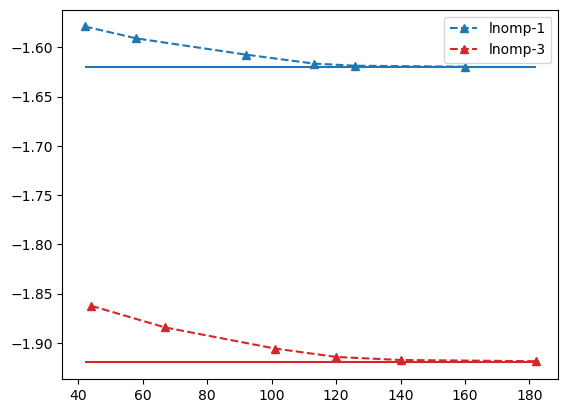

In [52]:
print(size1)
print(emp1)
print(size3)
print(emp3)
from matplotlib import pyplot as plt
plt.plot(size1, emp1, "^--", color="C0", label="lnomp-1")
plt.plot(size3, emp3, "^--", color="C3", label="lnomp-3")
plt.hlines(mymp.e_corr, xmin=min(np.hstack((size1,size3))), xmax=max(np.hstack((size1,size3))), colors='C0')
plt.hlines(mymp3.e_corr, xmin=min(np.hstack((size1,size3))), xmax=max(np.hstack((size1,size3))), colors='C3')
plt.legend()
plt.show()